# Passenger Counting Model Comparison

This notebook compares **different YOLO variants** and an **additional non-YOLO detector (RT-DETR)** on the same dataset and same training settings.

Goal: pick the most accurate model by validation `mAP50-95`.


In [1]:
# Cell 1 - Environment check
import os
import sys
import platform
from pathlib import Path

PROJECT_ROOT = Path.cwd()
print("Python:", sys.version)
print("Platform:", platform.platform())
print("Working directory:", PROJECT_ROOT)

conflict_names = ["torch.py", "torch", "ultralytics.py", "cv2.py", "pandas.py", "matplotlib.py"]
conflicts = [name for name in conflict_names if (PROJECT_ROOT / name).exists()]
print("Possible local conflicts:", conflicts if conflicts else "None")


Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Platform: Windows-10-10.0.26200-SP0
Working directory: C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting
Possible local conflicts: None


In [2]:
# Cell 2 - Optional package install (keep False for normal runs)
import subprocess

RUN_PACKAGE_INSTALL = False

if RUN_PACKAGE_INSTALL:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "ultralytics", "pandas", "matplotlib", "pyyaml", "pillow"])
    print("Package installation complete.")
else:
    print("Skipping package install. Set RUN_PACKAGE_INSTALL=True if needed.")


Skipping package install. Set RUN_PACKAGE_INSTALL=True if needed.


In [3]:
# Cell 3 - Imports
import json
import shutil
import time
import yaml
import torch
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

try:
    from IPython.display import display as ipy_display, Image as IPyImage
except Exception:
    ipy_display = None
    IPyImage = None


def display_item(item):
    if ipy_display is not None:
        ipy_display(item)
    else:
        print(item)


def image_widget(path, width=900):
    if IPyImage is not None:
        return IPyImage(filename=str(path), width=width)
    return f"Image file: {path}"


print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Torch: 2.12.0.dev20260301+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


In [4]:
# Cell 4 - Comparison configuration
from datetime import datetime

DATA_YAML_CANDIDATES = [
    PROJECT_ROOT / "ai_models" / "passenger_counting" / "datasets" / "smart_bus_final" / "data.yaml",
    PROJECT_ROOT / "datasets" / "smart_bus_final" / "data.yaml",
]

DATA_YAML = next((p for p in DATA_YAML_CANDIDATES if p.exists()), None)
if DATA_YAML is None:
    checked = "\n".join(str(p) for p in DATA_YAML_CANDIDATES)
    raise FileNotFoundError(f"Dataset YAML not found. Checked:\n{checked}")

# Compare YOLO models and one non-YOLO detector (RT-DETR)
MODEL_CANDIDATES = {
    "YOLOv8s": "yolov8s.pt",
    "YOLOv10s": "yolov10s.pt",
    "YOLO11s": "yolo11s.pt",
    "RTDETR-L": "rtdetr-l.pt",
}

COMPARE_EPOCHS = 20
IMG_SIZE = 640
BATCH = 8
PATIENCE = 20
WORKERS = 4
DEVICE = 0 if torch.cuda.is_available() else "cpu"

RUN_TRAINING = True

COMPARISON_ROOT = PROJECT_ROOT / "ai_models" / "passenger_counting" / "runs" / "detect" / "model_comparison"
ARTIFACT_DIR = COMPARISON_ROOT / "artifacts"
BEST_MODELS_DIR = ARTIFACT_DIR / "best_models"

COMPARISON_ROOT.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
BEST_MODELS_DIR.mkdir(parents=True, exist_ok=True)

comparison_config = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "dataset_yaml": str(DATA_YAML),
    "model_candidates": MODEL_CANDIDATES,
    "epochs": COMPARE_EPOCHS,
    "img_size": IMG_SIZE,
    "batch": BATCH,
    "patience": PATIENCE,
    "workers": WORKERS,
    "device": str(DEVICE),
    "cuda_available": torch.cuda.is_available(),
}

with open(ARTIFACT_DIR / "comparison_config.json", "w", encoding="utf-8") as f:
    json.dump(comparison_config, f, indent=2)

print("Dataset:", DATA_YAML)
print("Models:", MODEL_CANDIDATES)
print("Epochs:", COMPARE_EPOCHS)
print("Output root:", COMPARISON_ROOT)
print("Run training:", RUN_TRAINING)


Dataset: C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\datasets\smart_bus_final\data.yaml
Models: {'YOLOv8s': 'yolov8s.pt', 'YOLOv10s': 'yolov10s.pt', 'YOLO11s': 'yolo11s.pt', 'RTDETR-L': 'rtdetr-l.pt'}
Epochs: 20
Output root: C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\ai_models\passenger_counting\runs\detect\model_comparison
Run training: True


In [5]:
# Cell 5 - Train all candidate models
training_status = {}

if not RUN_TRAINING:
    for model_name, weight in MODEL_CANDIDATES.items():
        training_status[model_name] = {
            "status": "skipped",
            "weights": weight,
            "reason": "RUN_TRAINING=False",
        }
    print("Training skipped for all models.")
else:
    for model_name, weight in MODEL_CANDIDATES.items():
        print("\n" + "=" * 80)
        print(f"Training {model_name} ({weight})")
        print("=" * 80)

        start_time = time.time()
        try:
            model = YOLO(weight)
            train_result = model.train(
                data=str(DATA_YAML),
                epochs=COMPARE_EPOCHS,
                imgsz=IMG_SIZE,
                batch=BATCH,
                patience=PATIENCE,
                device=DEVICE,
                workers=WORKERS,
                cache=True,
                optimizer="AdamW",
                lr0=0.001,
                project=str(COMPARISON_ROOT),
                name=model_name,
                exist_ok=True,
                plots=True,
                pretrained=True,
                verbose=True,
            )

            run_dir = Path(getattr(train_result, "save_dir", COMPARISON_ROOT / model_name))
            training_status[model_name] = {
                "status": "completed",
                "weights": weight,
                "run_dir": str(run_dir),
                "elapsed_minutes": round((time.time() - start_time) / 60, 2),
            }
            print(f"Completed {model_name}")
        except Exception as e:
            training_status[model_name] = {
                "status": "failed",
                "weights": weight,
                "error": str(e),
                "elapsed_minutes": round((time.time() - start_time) / 60, 2),
            }
            print(f"Failed {model_name}: {e}")

with open(ARTIFACT_DIR / "training_status.json", "w", encoding="utf-8") as f:
    json.dump(training_status, f, indent=2)

print("Saved:", ARTIFACT_DIR / "training_status.json")
training_status



Training YOLOv8s (yolov8s.pt)
Ultralytics 8.4.41  Python-3.11.9 torch-2.12.0.dev20260301+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\datasets\smart_bus_final\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937,

C:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\autograd\graph.py:879: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/20      6.96G      1.448     0.4361     0.3239         36        640: 100% ━━━━━━━━━━━━ 252/252 2.1it/s 1:58<0.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 4.2it/s 7.4s0.2s
                   all        488       9028     0.0998      0.614      0.211     0.0534

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/20      6.71G      1.157     0.4684     0.1464        312        640: 0% ──────────── 0/252  0.5s

C:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\autograd\graph.py:879: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/20      6.78G     0.7538     0.7219     0.1067         23        640: 100% ━━━━━━━━━━━━ 252/252 2.4it/s 1:47<0.4ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 4.9it/s 6.3s0.2s
                   all        488       9028       0.31      0.425      0.257     0.0906

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/20      6.33G     0.9678     0.5286     0.1036        192        640: 0% ──────────── 0/252  0.4s

...

C:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\autograd\graph.py:879: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      19/20      6.47G     0.2521     0.3837    0.04078         52        640: 100% ━━━━━━━━━━━━ 252/252 2.5it/s 1:41<0.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 4.9it/s 6.3s0.2s
                   all        488       9028      0.899      0.923       0.96      0.789

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      20/20      6.85G     0.2597     0.3961    0.03897        131        640: 0% ──────────── 0/252  0.5s

C:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\autograd\graph.py:879: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      20/20      6.88G     0.2467     0.3753    0.03913         61        640: 100% ━━━━━━━━━━━━ 252/252 2.5it/s 1:41<0.4ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 5.0it/s 6.2s0.2s
                   all        488       9028      0.908      0.916      0.965      0.792

20 epochs completed in 0.622 hours.
Optimizer stripped from C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\ai_models\passenger_counting\runs\detect\model_comparison\RTDETR-L\weights\last.pt, 66.2MB
Optimizer stripped from C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\ai_models\passenger_counting\runs\detect\model_comparison\RTDETR-L\weights\best.pt, 66.2MB

Validating C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\ai_models\passenger_counting\runs\detect\model_comparison\RTDETR-L\weights\best.pt...
Ultralytics 8.4.41  Python-3.11.9 torch-2.12.0.dev20260301+cu128 CUDA:0 (NVIDI

{'YOLOv8s': {'status': 'completed',
  'weights': 'yolov8s.pt',
  'run_dir': 'C:\\suttle project\\smart-shuttle-ai-system\\ai_models\\passenger_counting\\ai_models\\passenger_counting\\runs\\detect\\model_comparison\\YOLOv8s',
  'elapsed_minutes': 9.69},
 'YOLOv10s': {'status': 'completed',
  'weights': 'yolov10s.pt',
  'run_dir': 'C:\\suttle project\\smart-shuttle-ai-system\\ai_models\\passenger_counting\\ai_models\\passenger_counting\\runs\\detect\\model_comparison\\YOLOv10s',
  'elapsed_minutes': 13.02},
 'YOLO11s': {'status': 'completed',
  'weights': 'yolo11s.pt',
  'run_dir': 'C:\\suttle project\\smart-shuttle-ai-system\\ai_models\\passenger_counting\\ai_models\\passenger_counting\\runs\\detect\\model_comparison\\YOLO11s',
  'elapsed_minutes': 10.04},
 'RTDETR-L': {'status': 'completed',
  'weights': 'rtdetr-l.pt',
  'run_dir': 'C:\\suttle project\\smart-shuttle-ai-system\\ai_models\\passenger_counting\\ai_models\\passenger_counting\\runs\\detect\\model_comparison\\RTDETR-L',
  'e

In [6]:
# Cell 6 - Validate all available best checkpoints and build comparison table
comparison_rows = []

for model_name, weight in MODEL_CANDIDATES.items():
    run_dir = COMPARISON_ROOT / model_name
    best_pt = run_dir / "weights" / "best.pt"
    results_csv = run_dir / "results.csv"

    if not best_pt.exists():
        print(f"Skipping {model_name}: missing {best_pt}")
        continue

    print("\n" + "-" * 80)
    print(f"Validating {model_name}")
    print("-" * 80)

    model = YOLO(str(best_pt))
    val_result = model.val(
        data=str(DATA_YAML),
        split="val",
        imgsz=IMG_SIZE,
        batch=BATCH,
        device=DEVICE,
        verbose=False,
    )

    precision = float(val_result.box.mp) if hasattr(val_result, "box") else 0.0
    recall = float(val_result.box.mr) if hasattr(val_result, "box") else 0.0
    map50 = float(val_result.box.map50) if hasattr(val_result, "box") else 0.0
    map5095 = float(val_result.box.map) if hasattr(val_result, "box") else 0.0

    copied_best = BEST_MODELS_DIR / f"{model_name}_best.pt"
    shutil.copy2(best_pt, copied_best)

    comparison_rows.append({
        "Model": model_name,
        "Base Weight": weight,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "mAP50": round(map50, 4),
        "mAP50-95": round(map5095, 4),
        "Run Folder": str(run_dir),
        "Best Checkpoint": str(best_pt),
        "Copied Best Checkpoint": str(copied_best),
        "Results CSV": str(results_csv) if results_csv.exists() else "Not found",
    })

comparison_df = pd.DataFrame(comparison_rows)

if comparison_df.empty:
    raise RuntimeError("No completed model checkpoints found. Run training first.")

comparison_df = comparison_df.sort_values(by="mAP50-95", ascending=False).reset_index(drop=True)
comparison_csv = ARTIFACT_DIR / "model_comparison_results.csv"
comparison_df.to_csv(comparison_csv, index=False)

best_row = comparison_df.iloc[0].to_dict()
best_selection = {
    "best_model_name": best_row["Model"],
    "best_base_weight": best_row["Base Weight"],
    "best_checkpoint": best_row["Best Checkpoint"],
    "best_mAP50_95": best_row["mAP50-95"],
    "dataset_yaml": str(DATA_YAML),
    "compare_epochs": COMPARE_EPOCHS,
    "comparison_csv": str(comparison_csv),
}

with open(ARTIFACT_DIR / "best_model_selection.json", "w", encoding="utf-8") as f:
    json.dump(best_selection, f, indent=2)

print("Saved:", comparison_csv)
print("Saved:", ARTIFACT_DIR / "best_model_selection.json")
display_item(comparison_df)



--------------------------------------------------------------------------------
Validating YOLOv8s
--------------------------------------------------------------------------------
Ultralytics 8.4.41  Python-3.11.9 torch-2.12.0.dev20260301+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 124.322.9 MB/s, size: 863.5 KB)
val: Scanning C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\datasets\smart_bus_final\labels\val.cache... 488 images, 52 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 488/488  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 61/61 19.8it/s 3.1s0.0s
                   all        488       9028      0.939      0.965      0.988      0.839
Speed: 0.6ms preprocess, 3.0ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to C:\suttle project

,Model,Base Weight,Precision,Recall,mAP50,mAP50-95,Run Folder,Best Checkpoint,Copied Best Checkpoint,Results CSV
0,YOLOv8s,yolov8s.pt,0.9391,0.9647,0.9876,0.8394,C:\suttle project\smart-shuttle-ai-system\ai_m...,C:\suttle project\smart-shuttle-ai-system\ai_m...,C:\suttle project\smart-shuttle-ai-system\ai_m...,C:\suttle project\smart-shuttle-ai-system\ai_m...
1,YOLOv10s,yolov10s.pt,0.9446,0.9403,0.9845,0.8228,C:\suttle project\smart-shuttle-ai-system\ai_m...,C:\suttle project\smart-shuttle-ai-system\ai_m...,C:\suttle project\smart-shuttle-ai-system\ai_m...,C:\suttle project\smart-shuttle-ai-system\ai_m...
2,YOLO11s,yolo11s.pt,0.9421,0.9545,0.9851,0.8164,C:\suttle project\smart-shuttle-ai-system\ai_m...,C:\suttle project\smart-shuttle-ai-system\ai_m...,C:\suttle project\smart-shuttle-ai-system\ai_m...,C:\suttle project\smart-shuttle-ai-system\ai_m...
3,RTDETR-L,rtdetr-l.pt,0.9083,0.9145,0.9647,0.7935,C:\suttle project\smart-shuttle-ai-system\ai_m...,C:\suttle project\smart-shuttle-ai-system\ai_m...,C:\suttle project\smart-shuttle-ai-system\ai_m...,C:\suttle project\smart-shuttle-ai-system\ai_m...


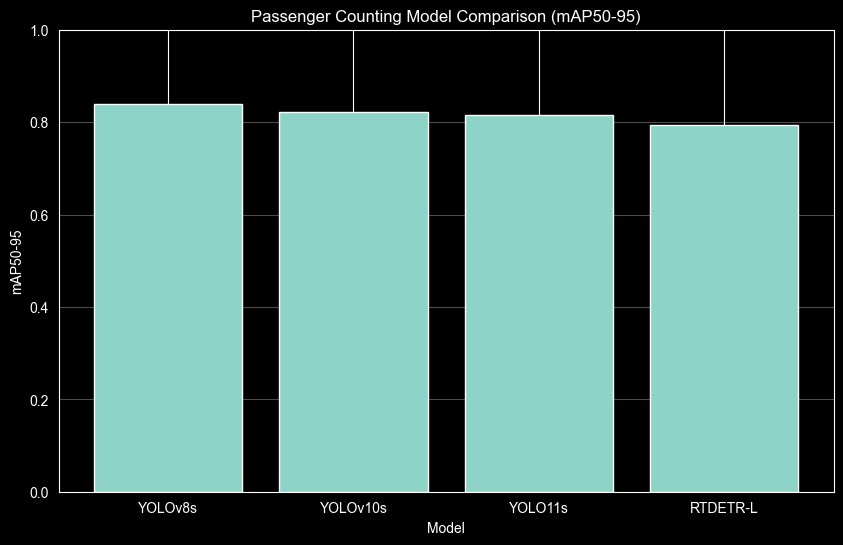

Saved: C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\ai_models\passenger_counting\runs\detect\model_comparison\artifacts\comparison_chart.png


In [7]:
# Cell 7 - Plot comparison chart
if "comparison_df" in globals() and not comparison_df.empty:
    plt.figure(figsize=(10, 6))
    plt.bar(comparison_df["Model"], comparison_df["mAP50-95"])
    plt.title("Passenger Counting Model Comparison (mAP50-95)")
    plt.xlabel("Model")
    plt.ylabel("mAP50-95")
    plt.ylim(0, 1.0)
    plt.grid(axis="y", alpha=0.3)

    chart_path = ARTIFACT_DIR / "comparison_chart.png"
    plt.savefig(chart_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", chart_path)
else:
    print("comparison_df is empty.")


In [8]:
# Cell 8 - Quick summary
if "best_selection" in globals():
    print("Best model:", best_selection["best_model_name"])
    print("Base weight:", best_selection["best_base_weight"])
    print("Best mAP50-95:", best_selection["best_mAP50_95"])
    print("Best checkpoint:", best_selection["best_checkpoint"])
else:
    print("best_selection is not available yet.")


Best model: YOLOv8s
Base weight: yolov8s.pt
Best mAP50-95: 0.8394
Best checkpoint: C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\ai_models\passenger_counting\runs\detect\model_comparison\YOLOv8s\weights\best.pt
